In [14]:
!pip install xgboost

  Using cached xgboost-3.0.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.0.0-py3-none-macosx_12_0_arm64.whl (2.0 MB)


In [675]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import numpy as np

In [18]:
# Carga tu dataset
df = pd.read_csv('idealista_procesado.csv')

In [20]:
# Variables que no usarás como input
drop_cols = ['titulo', 'calle', 'fecha_publicacion', 'zona']

In [22]:
# Selecciona las features y la variable objetivo
X = df.drop(columns=drop_cols + ['precio'])
y = df['precio']

In [24]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
# Crear el modelo
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

# Entrenar
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [28]:
# Predicciones
y_pred = model.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [30]:
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

MAE:  58937.26
RMSE: 150148.36
R²:   0.94


In [32]:
# Crear un DataFrame con los valores reales y los predichos
comparison_df = pd.DataFrame({
    'precio_real': y_test.values,
    'precio_predicho': y_pred
})
# Diferencia absoluta entre real y predicho
comparison_df['diferencia_absoluta'] = abs(comparison_df['precio_real'] - comparison_df['precio_predicho'])

# Porcentaje de error relativo respecto al precio real
comparison_df['error_relativo_%'] = 100 * comparison_df['diferencia_absoluta'] / comparison_df['precio_real']

In [34]:
print(comparison_df.round(2).head(30))

    precio_real  precio_predicho  diferencia_absoluta  error_relativo_%
0        138000     1.429620e+05              4961.95              3.60
1        112000     1.268200e+05             14820.01             13.23
2        167000     1.668920e+05               107.97              0.06
3        180000     1.736327e+05              6367.31              3.54
4        134000     1.136807e+05             20319.34             15.16
5       1200000     1.586963e+06            386963.38             32.25
6        549000     5.798791e+05             30879.06              5.62
7        325000     3.576087e+05             32608.72             10.03
8        170000     1.840218e+05             14021.81              8.25
9        339000     3.082147e+05             30785.28              9.08
10       159000     1.516896e+05              7310.39              4.60
11      1600000     1.839556e+06            239555.62             14.97
12       850000     6.888118e+05            161188.19           

Matplotlib is building the font cache; this may take a moment.


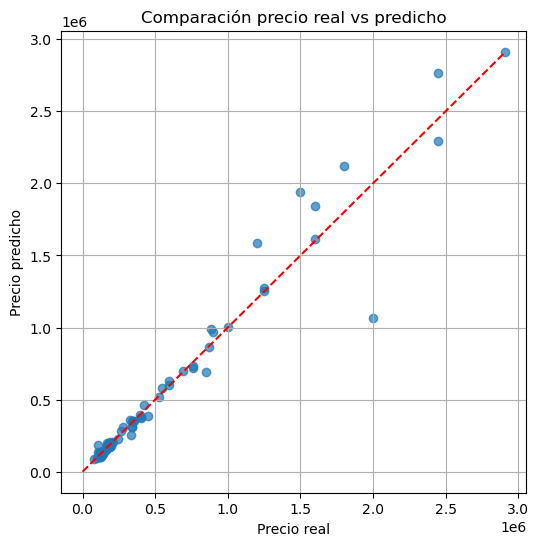

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(comparison_df['precio_real'], comparison_df['precio_predicho'], alpha=0.7)
plt.plot([0, max(comparison_df['precio_real'])], [0, max(comparison_df['precio_real'])], color='red', linestyle='--')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Comparación precio real vs predicho')
plt.grid(True)
plt.show()

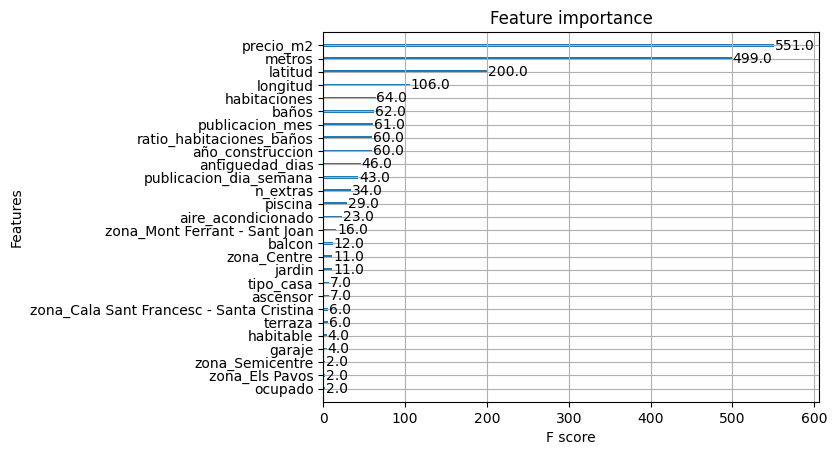

In [13]:
import xgboost as xgb
xgb.plot_importance(model)
plt.show()

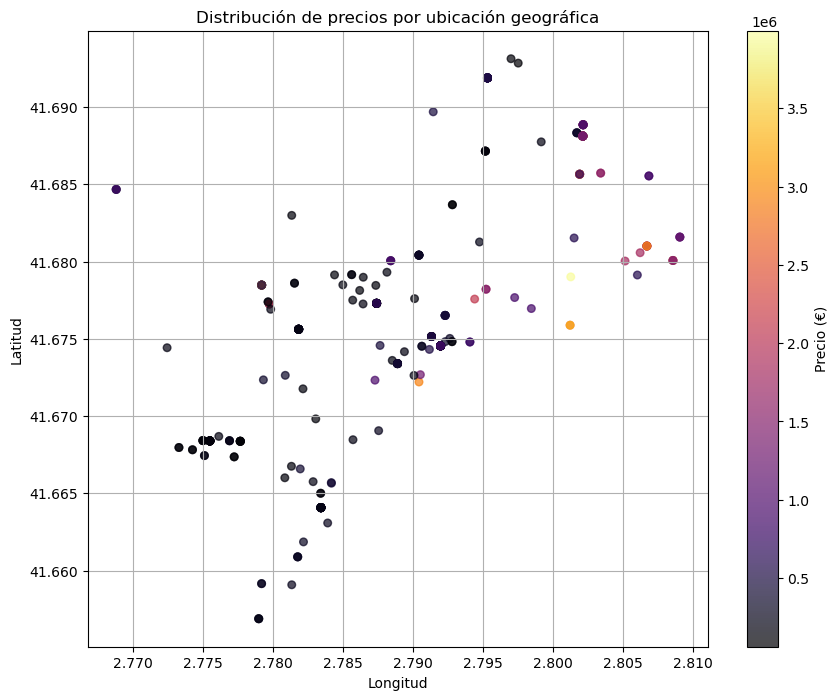

In [794]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df['longitud'],
    df['latitud'],
    c=df['precio'],  # el color representa el precio
    cmap='inferno',  # o plasma, inferno, coolwarm...
    s=30,            # tamaño de los puntos
    alpha=0.7        # transparencia
)

plt.colorbar(scatter, label='Precio (€)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución de precios por ubicación geográfica')
plt.grid(True)
plt.show()

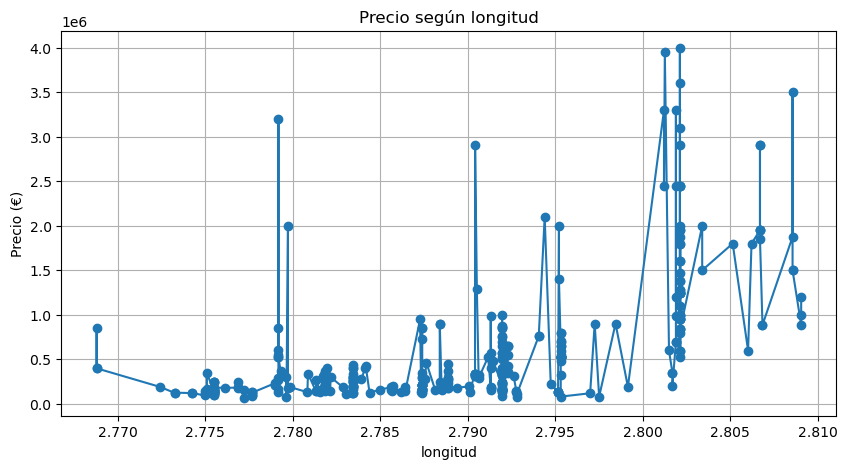

In [798]:
df_sorted = df.sort_values(by="longitud")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["longitud"], df_sorted["precio"], marker='o')
plt.xlabel("longitud")
plt.ylabel("Precio (€)")
plt.title("Precio según longitud")
plt.grid(True)
plt.show()

In [38]:
!pip install folium

In [40]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import branca.colormap as cm

In [44]:
# Asegúrate de tener columnas 'lat', 'lon' y 'precio'
df_mapa = df.dropna(subset=['latitud', 'longitud', 'precio'])

# Crear un colormap (de menor a mayor precio)
min_price, max_price = df_mapa['precio'].min(), df_mapa['precio'].max()
colormap = cm.linear.YlOrRd_09.scale(min_price, max_price)
colormap.caption = 'Precio (€)'

# Centro del mapa
centro = [df_mapa['latitud'].mean(), df_mapa['longitud'].mean()]
m = folium.Map(location=centro, zoom_start=13)

# Agrupador de marcadores
marker_cluster = MarkerCluster().add_to(m)

# Añadir puntos
for _, row in df_mapa.iterrows():
    color = colormap(row['precio'])
    popup = f"{row['precio']:.0f} €"
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=popup
    ).add_to(marker_cluster)

# Añadir leyenda
colormap.add_to(m)

# Guardar el mapa
m.save("mapa_pisos_coloreado.html")
print("✅ Mapa guardado como 'mapa_pisos_coloreado.html'")


✅ Mapa guardado como 'mapa_pisos_coloreado.html'


# Mapa de blanes por precios

In [51]:
# Datos válidos
df_mapa = df.dropna(subset=['latitud', 'longitud', 'precio'])

# Colormap
min_price, max_price = df_mapa['precio'].min(), df_mapa['precio'].max()
colormap = cm.linear.YlOrRd_09.scale(min_price, max_price)
colormap.caption = 'Precio (€)'

# Crear mapa
centro = [df_mapa['latitud'].mean(), df_mapa['longitud'].mean()]
m = folium.Map(location=centro, zoom_start=13)

# Añadir marcadores directamente al mapa (sin cluster)
for _, row in df_mapa.iterrows():
    color = colormap(row['precio'])
    popup = f"{row['precio']:.0f} €"
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=popup
    ).add_to(m)

# Añadir leyenda
colormap.add_to(m)

# Mostrar mapa
m


In [56]:
df_mapa = df.dropna(subset=['latitud', 'longitud', 'precio'])
print(f"Pisos con coordenadas: {len(df_mapa)}")

Pisos con coordenadas: 349


In [60]:
import seaborn as sns

In [172]:
# Asegúrate de tener 'zona' como columna textual (no one-hot)
# Si no existe, reconstruye desde las columnas one-hot:
if 'zona' not in df.columns:
    zona_cols = [col for col in df.columns if col.startswith('zona_')]
    df['zona'] = df[zona_cols].idxmax(axis=1).str.replace('zona_', '')

# Filtrar datos válidos
df_mapa = df.dropna(subset=['latitud', 'longitud', 'zona'])

# Crear un color por zona con seaborn
zonas_unicas = df_mapa['zona'].unique()
palette = sns.color_palette('Set2', len(zonas_unicas)).as_hex()
color_por_zona = dict(zip(zonas_unicas, palette))

# Mapa de blanes por zonas

In [681]:
centro = [df_mapa['latitud'].mean(), df_mapa['longitud'].mean()]
m = folium.Map(location=centro, zoom_start=13)

def jitter_coords(lat, lon, factor=0.0005):
    lat += np.random.uniform(-factor, factor)
    lon += np.random.uniform(-factor, factor)
    return lat, lon

# Paso 1: identificar coordenadas duplicadas
duplicadas = df_mapa.groupby(['latitud', 'longitud']).size().reset_index(name='cuenta')
coordenadas_duplicadas = set(
    tuple(x) for x in duplicadas[duplicadas['cuenta'] > 1][['latitud', 'longitud']].values
)

# Paso 2: pintar el mapa
for _, row in df_mapa.iterrows():
    zona = row['zona']
    color = color_por_zona.get(zona, 'gray')
    popup = f"{row['zona']}<br>{row['precio']} €"

    lat = row['latitud']
    lon = row['longitud']

    # Si las coordenadas están duplicadas, aplicar jitter
    if (lat, lon) in coordenadas_duplicadas:
        lat, lon = jitter_coords(lat, lon)

    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=popup
    ).add_to(m)


In [683]:
# Mostrar mapa
m

# Ver las zonas/pisos del mapa

In [686]:
# Asegúrate de tener la columna 'zona'
conteo_zonas = df_mapa['zona'].value_counts().sort_values(ascending=False)
print(conteo_zonas)

zona
Centre                                 86
Cala Sant Francesc - Santa Cristina    68
Els Pins                               45
Semicentre                             42
La Plantera                            40
Mont Ferrant - Sant Joan               26
Urbanitzacions                         22
Els Pavos                              20
Name: count, dtype: int64


In [688]:
coordenadas_duplicadas = df_mapa.groupby(['latitud', 'longitud']).size().reset_index(name='cuenta')
coordenadas_duplicadas = coordenadas_duplicadas[coordenadas_duplicadas['cuenta'] > 1]
print(coordenadas_duplicadas)

      latitud  longitud  cuenta
0   41.656885  2.778965       3
2   41.659156  2.779170       2
3   41.660890  2.781749       3
6   41.664074  2.783409      21
7   41.665005  2.783392       2
14  41.667362  2.777212       2
15  41.667444  2.775086       2
16  41.667821  2.774232       2
17  41.667967  2.773264       2
18  41.668370  2.777646       6
19  41.668394  2.775473      19
20  41.668406  2.776876       3
21  41.668416  2.774977       4
33  41.673397  2.788882       9
38  41.674521  2.790619       2
39  41.674547  2.791958      38
41  41.674797  2.794054       2
42  41.674819  2.792776       2
45  41.675151  2.791310       7
46  41.675619  2.781819      16
47  41.675883  2.801213       2
48  41.676517  2.792285       5
51  41.677252  2.779719       2
53  41.677296  2.787386      22
54  41.677392  2.779634       2
60  41.678211  2.795209       2
62  41.678479  2.779174       8
64  41.678603  2.781522       2
69  41.679155  2.785606       2
72  41.680057  2.788394       3
73  41.6

# Mapa de con las zonas renderizadas

In [691]:
zonas = {
    "Centre": [
        [41.669835, 2.788248],
        [41.671178, 2.785606],
        [41.674806, 2.784742],
        [41.677486, 2.790112],
        [41.676708, 2.794305],
        [41.676657, 2.799202],
        [41.676279, 2.798545],
        [41.674566, 2.793592],
    ],
    "La Plantera": [
        [41.669103, 2.778667],
        [41.669185, 2.775955],
        [41.670189, 2.775442],
        [41.669377, 2.772107],
        [41.667816, 2.770311],
        [41.667360, 2.772486],
        [41.666986, 2.775112],
        [41.668081, 2.779058],
        [41.669103, 2.778667],
    ],
    "Els Pins": [
        [41.669693, 2.788136],
        [41.669150, 2.781543],
        [41.670055, 2.780569],
        [41.669188, 2.778760],
        [41.668079, 2.779118],
        [41.666816, 2.775072],
        [41.653220, 2.778913],
        [41.669693, 2.788136],
    ],
    "Els Pavos": [
        [41.675803, 2.775642],
        [41.677727, 2.783575],
        [41.677727, 2.783575],
        [41.675775, 2.784536],
        [41.673032, 2.784962],
        [41.671206, 2.785412],
        [41.669868, 2.788031],
        [41.669287, 2.781557],
        [41.673296, 2.777355],
    ],
    "Semicentre": [
        [41.674899, 2.784741],
        [41.675831, 2.784630],
        [41.679440, 2.783090],
        [41.683019, 2.790460],
        [41.685145, 2.793965],
        [41.67766266268316, 2.7900361570456016],
    ],
    "Mont Ferrant - Sant Joan": [
        [41.677806, 2.790107],
        [41.685197, 2.793994],
        [41.688355, 2.799202],
        [41.688815, 2.801481],
        [41.687338, 2.801118],
        [41.685057, 2.800840],
        [41.681905, 2.802154],
        [41.676854, 2.799362],
        [41.676825, 2.794382],
    ],
    "Cala Sant Francesc - Santa Cristina": [
        [41.688946, 2.801715],
        [41.691047, 2.806117],
        [41.689514, 2.811148],
        [41.687473, 2.815286],
        [41.686241, 2.816513],
        [41.683131, 2.814934],
        [41.680862, 2.810754],
        [41.679226, 2.808502],
        [41.678972, 2.80701],
        [41.677399, 2.807278],
        [41.675835, 2.802681],
        [41.674311, 2.803154],
        [41.674150, 2.801250],
        [41.676338, 2.798932],
        [41.682015, 2.802361],
        [41.685306, 2.801270],
        
    ]
}

In [693]:
import random

In [695]:
color_por_zona = {
    "Centre": "#1f77b4",
    "La Plantera": "#ff7f0e",
    "Els Pins": "#2ca02c",
    "Els Pavos": "#d62728",
    "Semicentre": "#9467bd",
    "Mont Ferrant - Sant Joan": "#8c564b",
    "Cala Sant Francesc - Santa Cristina": "#e377c2"
}

In [697]:
from folium.features import DivIcon
import numpy as np

def calcular_centroide(coords):
    latitudes = [pt[0] for pt in coordenadas]
    longitudes = [pt[1] for pt in coordenadas]
    lat = (max(latitudes) + min(latitudes)) / 2
    lon = (max(longitudes) + min(longitudes)) / 2
    return lat, lon

In [699]:

centro = [df_mapa['latitud'].mean(), df_mapa['longitud'].mean()]
m = folium.Map(location=centro, zoom_start=13)

def jitter_coords(lat, lon, factor=0.0005):
    lat += np.random.uniform(-factor, factor)
    lon += np.random.uniform(-factor, factor)
    return lat, lon

# Paso 1: identificar coordenadas duplicadas
duplicadas = df_mapa.groupby(['latitud', 'longitud']).size().reset_index(name='cuenta')
coordenadas_duplicadas = set(
    tuple(x) for x in duplicadas[duplicadas['cuenta'] > 1][['latitud', 'longitud']].values
)

for nombre_zona, coordenadas in zonas.items():
    color = color_por_zona.get(nombre_zona, "#cccccc")  # color por defecto si falta
    folium.Polygon(
        locations=coordenadas,
        color=color,
        weight=2,             # thinner border
        opacity=0.8,          # border opacity
        fill=True,
        fill_color=color,
        fill_opacity=0.2,
        tooltip=nombre_zona
    ).add_to(m)

    # Calcular centroide y añadir texto
    lat, lon = calcular_centroide(coordenadas)
    folium.map.Marker(
        [lat, lon],
        icon=DivIcon(
            icon_size=(150,50),
            icon_anchor=(+20,0),
            html=f'<div style="font-size: 9px; color: black; font-weight: bold;">{nombre_zona}</div>',
        )
    ).add_to(m)

# Paso 2: pintar el mapa
# Detectar las columnas de tipo
tipo_cols = [col for col in df_mapa.columns if col.startswith('tipo_')]

# Crear una nueva columna 'tipo' con el nombre de la columna que tiene un 1
df_mapa['tipo'] = df_mapa[tipo_cols].idxmax(axis=1).str.replace('tipo_', '')

for _, row in df_mapa.iterrows():
    zona = row['zona']
    color = color_por_zona.get(zona, 'gray')

    lat = row['latitud']
    lon = row['longitud']

    tipo = row.get('tipo', 'Desconocido')
    precio = row.get('precio', 0)
    metros = row.get('metros', 0)

    popup = f"""
    <b>{tipo.capitalize()}</b><br>
    💰 {precio:,.0f} €<br>
    📐 {metros:.0f} m²
    """

    # Si las coordenadas están duplicadas, aplicar jitter
    if (lat, lon) in coordenadas_duplicadas:
        lat, lon = jitter_coords(lat, lon)

    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=popup
    ).add_to(m)

m

# Predecir el precio de un piso

In [626]:
# Diccionario con los valores reales del inmueble a predecir
nuevo_piso = {
    'metros': 120,
    'habitaciones': 3,
    'baños': 2,
    'año_construccion': 1995,
    'terraza': 0,
    'balcon': 1,
    'garaje': 1,
    'jardin': 1,
    'aire_acondicionado': 1,
    'zona_Centre': 1,
    'tipo_casa': 0,
    'tipo_piso': 1,
    # Rellena el resto de columnas como 0
}

In [628]:
# Lista con todas las columnas del modelo (exactamente las mismas)
columnas_modelo = list(X_train.columns)  # o guárdalas tú mismo

In [630]:
def estimar_precio(input_dict, columnas_modelo, model):
    for col in columnas_modelo:
        if col not in input_dict:
            input_dict[col] = 0
    X_input = pd.DataFrame([input_dict])[columnas_modelo]
    return model.predict(X_input)[0]

In [632]:
precio_estimado = estimar_precio(nuevo_piso, columnas_modelo, model)
print(f"💰 Precio estimado: {precio_estimado:,.0f} €")


💰 Precio estimado: 143,495 €


# Procesado de datos (SOBRE O INFRA DE UNA PROPIEDAD POR ZONA)

In [701]:
# Asegúrate de tener 'zona' como columna textual (no one-hot)
# Si no existe, reconstruye desde las columnas one-hot:
if 'zona' not in df.columns:
    zona_cols = [col for col in df.columns if col.startswith('zona_')]
    df['zona'] = df[zona_cols].idxmax(axis=1).str.replace('zona_', '')

# Obtener el precio por zona medio

In [704]:
precio_medio_zona = df.groupby('zona')['precio'].mean().sort_values(ascending=False)
print(precio_medio_zona)

zona
Cala Sant Francesc - Santa Cristina    1.668588e+06
Mont Ferrant - Sant Joan               7.825000e+05
Urbanitzacions                         5.089273e+05
Centre                                 4.294093e+05
Els Pavos                              2.504900e+05
Semicentre                             2.461381e+05
Els Pins                               2.456289e+05
La Plantera                            1.488475e+05
Name: precio, dtype: float64


In [706]:
precio_m2_medio_zona = df.groupby('zona')['precio_m2'].mean().sort_values(ascending=False)
print(precio_m2_medio_zona)

zona
Cala Sant Francesc - Santa Cristina    4407.148972
Els Pins                               3207.035242
Mont Ferrant - Sant Joan               3014.491072
Centre                                 2739.436373
Els Pavos                              2378.365126
Semicentre                             1943.947672
La Plantera                            1934.783191
Urbanitzacions                         1915.401450
Name: precio_m2, dtype: float64


In [708]:
# Añadir columna con media de su zona
df['precio_m2_zona_media'] = df['zona'].map(precio_m2_medio_zona)

# Calcular si está por encima o por debajo
df['por_encima_media'] = df['precio_m2'] > df['precio_m2_zona_media']

In [710]:
m = folium.Map(location=[df['latitud'].mean(), df['longitud'].mean()], zoom_start=13)

for _, row in df.iterrows():
    lat = row['latitud']
    lon = row['longitud']
    zona = row['zona']
    precio = row['precio']
    metros = row['metros']
    tipo = row.get('tipo', 'Inmueble')

    color = 'green' if not row['por_encima_media'] else 'red'  # ganga = verde, caro = rojo

    popup = f"""
    <b>{tipo.capitalize()}</b><br>
    🏘 Zona: {zona}<br>
    💰 {precio:,.0f} €<br>
    📐 {metros:.0f} m²<br>
    {'✅ Por debajo de la media' if not row['por_encima_media'] else '⚠️ Por encima de la media'}
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=folium.Popup(popup, max_width=250)
    ).add_to(m)

In [712]:
m

# Procesado de datos (SOBRE O INFRA DE UNA PROPIEDAD POR ZONA) UTILIZANDO EL MODELO

In [715]:
features = list(X.columns)
df['precio_estimado'] = model.predict(df[features])
# Consideramos ganga si el precio real es al menos un 10% más barato que el estimado
df['ganga'] = df['precio'] < df['precio_estimado'] * 0.9

In [717]:
for _, row in df.iterrows():
    color = 'green' if row['ganga'] else 'red'

    popup = f"""
    🏘 Zona: {row['zona']}<br>
    💰 Precio real: {row['precio']:,.0f} €<br>
    💡 Precio estimado: {row['precio_estimado']:,.0f} €<br>
    📐 {row['metros']:.0f} m²<br>
    {'✅ GANGA' if row['ganga'] else '❌ No ganga'}
    """

    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=folium.Popup(popup, max_width=250)
    ).add_to(m)
m

In [719]:
# definimos umbral de segun underprice, fair or overpriced

In [721]:
df['diferencia'] = df['precio'] - df['precio_estimado']

In [723]:
def clasificar_valor(dif, umbral=2000):
    if dif < -umbral:
        return 'ganga'
    elif abs(dif) <= umbral:
        return 'justo'
    else:
        return 'caro'

df['categoria_valor'] = df['diferencia'].apply(clasificar_valor)

In [725]:
colores_valor = {
    'ganga': 'green',
    'justo': 'blue',
    'caro': 'red'
}

In [727]:
duplicadas = df_mapa.groupby(['latitud', 'longitud']).size().reset_index(name='cuenta')
coordenadas_duplicadas = set(
    tuple(x) for x in duplicadas[duplicadas['cuenta'] > 1][['latitud', 'longitud']].values
)

for _, row in df.iterrows():
    categoria = row['categoria_valor']
    color = colores_valor.get(categoria, 'gray')

    popup = f"""
    🏘 Zona: {row['zona']}<br>
    💰 Precio real: {row['precio']:,.0f} €<br>
    💡 Estimado: {row['precio_estimado']:,.0f} €<br>
    📐 {row['metros']:.0f} m²<br>
    {'🟢 GANGA' if categoria == 'ganga' else ('🔵 PRECIO JUSTO' if categoria == 'justo' else '🔴 CARO')}
    """

    lat = row['latitud']
    lon = row['longitud']
    
    if (lat, lon) in coordenadas_duplicadas:
        lat, lon = jitter_coords(lat, lon)
    
    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=folium.Popup(popup, max_width=250)
    ).add_to(m)
m

In [742]:
import requests
def buscar_pois_cercanos(lat, lon, tipo='supermarket', radio=500):
    """
    Consulta si hay algún lugar del tipo dado (e.g. supermarket, school)
    cerca de las coordenadas lat/lon usando Overpass API.
    """
    query = f"""
    [out:json];
    (
      node["amenity"="{tipo}"](around:{radio},{lat},{lon});
      way["amenity"="{tipo}"](around:{radio},{lat},{lon});
      relation["amenity"="{tipo}"](around:{radio},{lat},{lon});
    );
    out center;
    """

    url = "https://overpass-api.de/api/interpreter"
    response = requests.post(url, data={"data": query})

    if response.status_code == 200:
        data = response.json()
        return len(data['elements']) > 0, data['elements']
    else:
        print("❌ Error en la consulta:", response.status_code)
        return False, []


In [748]:
lat = 41.672333
lon = 2.779320

hay_super, super_data = buscar_pois_cercanos(lat, lon, tipo="supermarket")
hay_school, school_data = buscar_pois_cercanos(lat, lon, tipo="school")

print("🛒 Supermercado cerca:", "Sí" if hay_super else "No")
print("🏫 Escuela cerca:", "Sí" if hay_school else "No")

🛒 Supermercado cerca: No
🏫 Escuela cerca: Sí


In [750]:
def mapa_con_pois(lat, lon, pois, radio=500, tipo="POI"):
    m = folium.Map(location=[lat, lon], zoom_start=16)

    # Círculo de radio
    folium.Circle(
        location=[lat, lon],
        radius=radio,
        color='blue',
        fill=True,
        fill_opacity=0.1,
        tooltip=f"Zona de búsqueda ({radio} m)"
    ).add_to(m)

    # Punto central (tu ubicación)
    folium.Marker(
        [lat, lon],
        popup="Ubicación central",
        icon=folium.Icon(color="black", icon="home")
    ).add_to(m)

    # Añadir POIs encontrados
    for poi in pois:
        lat_poi = poi.get('lat') or poi.get('center', {}).get('lat')
        lon_poi = poi.get('lon') or poi.get('center', {}).get('lon')
        nombre = poi.get('tags', {}).get('name', tipo.capitalize())

        if lat_poi and lon_poi:
            folium.Marker(
                [lat_poi, lon_poi],
                popup=nombre,
                icon=folium.Icon(color='green', icon='info-sign')
            ).add_to(m)

    return m


In [776]:
lat = 41.672333
lon = 2.779320

hay, resultados = buscar_pois_cercanos(lat, lon, tipo="restaurant", radio=500)

mapa = mapa_con_pois(lat, lon, resultados, radio=1000, tipo="restaurant")
mapa

In [781]:
import joblib

In [783]:
# Guarda el modelo
joblib.dump(model, 'modelo_xgboost.pkl')

['modelo_xgboost.pkl']